# Tutorial 2/3 -- Why Noise Breaks the Naive Inverse
### Finer grids make it worse (with a noise-free control)

**Recap of Part 1.** Forward $\alpha \to T$: $T(x)=q\,x(L-x)/(2\alpha)$, here $5x(1-x)$. Inverse on *clean* data via
$\alpha^{\rm FDM}_i=-q\Delta x^2/(T_{i+1}-2T_i+T_{i-1})$ works to ~$10^{-14}$ (stencil exact on quadratics; leftover is round-off).

**Learning goals (Part 2).** After this notebook you can:
1. Derive $\mathrm{Std}(\epsilon_{T''})=\sqrt6\ \sigma/\Delta x^2$ and verify it numerically.
2. Show the pointwise inverse fails at 1% noise (~half unphysical, ~6% usable).
3. Show refinement hurts (usable % $\to 0$) and that even round-off follows the same law.

*Time: ~35 min. Self-contained: run top to bottom. Part 1 helps but is not required.*


## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
})

# Problem parameters (same in all three tutorials of this series)
L = 1.0
q = 1.0
T0 = 0.0
TL = 0.0
alpha_true = 0.1

Txx_true = -q / alpha_true   # exact (constant) curvature we hope to recover

print(f"L = {L}, q = {q}, T0 = {T0}, TL = {TL}")
print(f"True alpha = {alpha_true}   ->   true T'' = {Txx_true}")


def analytical_temperature(x, alpha, L=1.0, q=1.0, T0=0.0, TL=0.0):
    # Exact solution of -alpha*T'' = q with Dirichlet boundary conditions.
    return T0 + (TL - T0) * x / L + (q / (2 * alpha)) * x * (L - x)


def fdm_second_derivative(T, dx):
    return (T[2:] - 2 * T[1:-1] + T[:-2]) / dx**2


def inverse_alpha_fdm(T, dx, q=1.0):
    Txx = fdm_second_derivative(T, dx)
    return -q / Txx, Txx


def add_noise(T, relative_noise, seed=42):
    rng = np.random.default_rng(seed)
    sigma = relative_noise * np.max(np.abs(T))
    return T + rng.normal(0.0, sigma, T.shape), sigma

# Default grid for single-realisation figures in this tutorial
x = np.linspace(0.0, L, 101)
T_true = analytical_temperature(x, alpha_true, L, q, T0, TL)
dx = x[1] - x[0]


L = 1.0, q = 1.0, T0 = 0.0, TL = 0.0
True alpha = 0.1   ->   true T'' = -10.0


## 5. Adding measurement noise

Real sensors are imperfect. We model the measurement as

$$
T_i^{\rm obs}=T_i^{\rm true}+\epsilon_i,\qquad \epsilon_i\sim\mathcal N(0,\sigma^2)\ \text{(independent)}
$$

and define the noise level relative to the peak temperature, $\sigma=\eta\,T_{\max}$. We test $\eta = 0\%,\,1\%,\,5\%,\,10\%$.

**What to look for:** the noisy data still look like a clean parabola with a bit of scatter. Nobody would call 1% noise "bad data". Hold that thought.

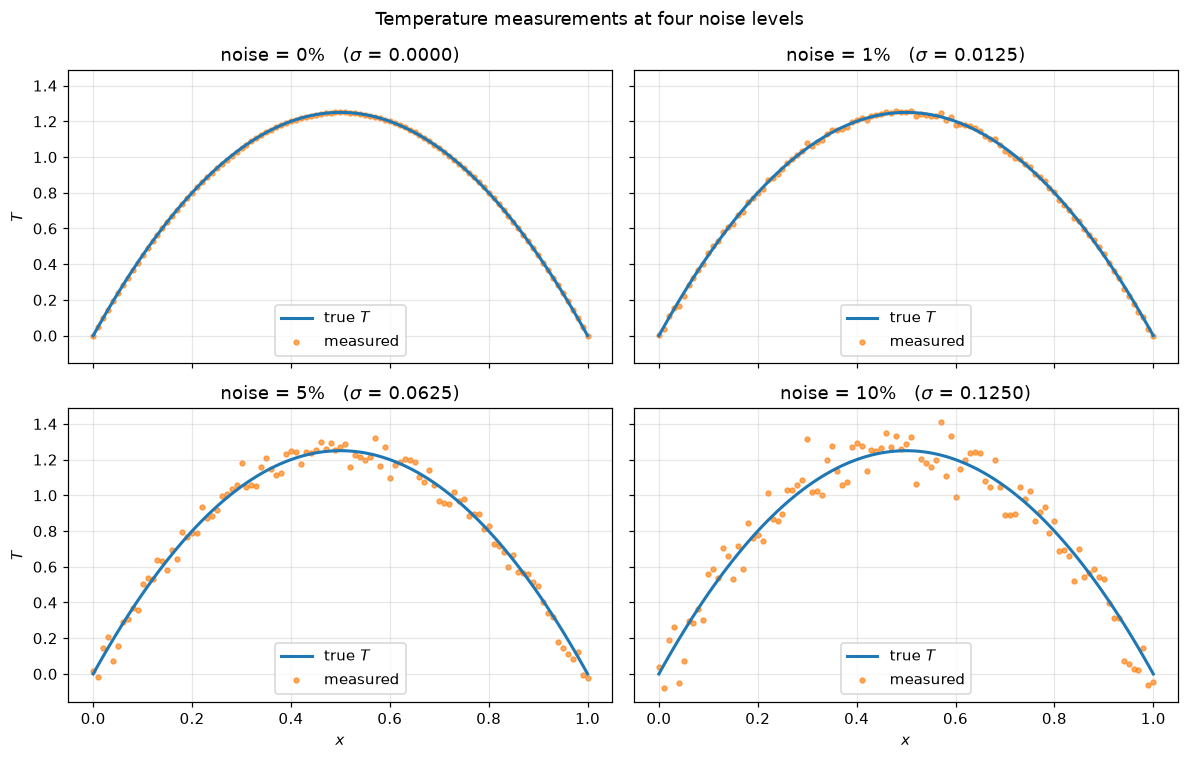

In [2]:
def add_noise(T, relative_noise, seed=42):
    rng = np.random.default_rng(seed)
    sigma = relative_noise * np.max(np.abs(T))
    return T + rng.normal(0.0, sigma, T.shape), sigma

levels = [0.00, 0.01, 0.05, 0.10]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, eta in zip(axes.ravel(), levels):
    Tn, sigma = add_noise(T_true, eta, seed=42)
    ax.plot(x, T_true, lw=2, label="true $T$")
    ax.scatter(x, Tn, s=10, alpha=0.65, color="C1", label="measured")
    ax.set_title(f"noise = {eta:.0%}   ($\\sigma$ = {sigma:.4f})")
    ax.legend(loc="lower center")
for ax in axes[-1, :]: ax.set_xlabel("$x$")
for ax in axes[:, 0]:  ax.set_ylabel("$T$")
fig.suptitle("Temperature measurements at four noise levels")
fig.tight_layout()
plt.show()

## 6. Why differentiating twice amplifies noise

### 6.1 The algebra

Insert $T^{\rm obs}=T^{\rm true}+\epsilon$ into the central difference. Because differencing is linear, the result splits into signal plus noise:

$$
D_{xx}T_i^{\rm obs}
= \underbrace{D_{xx}T_i^{\rm true}}_{\text{what we want: } -q/\alpha}
\;+\;
\underbrace{\frac{\epsilon_{i+1}-2\epsilon_i+\epsilon_{i-1}}{\Delta x^2}}_{\epsilon_{T''}\ \text{(noise)}} .
$$

For independent noise, variances add (and the coefficient $-2$ is squared):

$$
\operatorname{Var}(\epsilon_{i+1}-2\epsilon_i+\epsilon_{i-1})=\sigma^2+4\sigma^2+\sigma^2=6\sigma^2
\;\;\Longrightarrow\;\;
\boxed{\operatorname{Std}(\epsilon_{T''})=\frac{\sqrt6\,\sigma}{\Delta x^{2}}} .
$$

> **The key scaling:** the noise in $T''$ grows like $\Delta x^{-2}$. The signal $T''=-q/\alpha$ does not depend on $\Delta x$ at all.

### 6.2 The same thing in raw numbers

Before dividing by $\Delta x^2$, each stencil contains a **signal** of size $|T''|\,\Delta x^2$ and **noise** of size $\sqrt6\,\sigma$. Compare them for 1% noise on our 101-point grid:

In [3]:
eta = 0.01
T_noisy, sigma = add_noise(T_true, eta, seed=42)

signal_per_stencil = abs(Txx_true) * dx**2
noise_per_stencil  = np.sqrt(6) * sigma
theory_std = noise_per_stencil / dx**2

print(f"sigma (1% of T_max)                : {sigma:.4f}")
print(f"signal in one stencil |T''| dx^2   : {signal_per_stencil:.4f}")
print(f"noise  in one stencil sqrt(6)*sigma: {noise_per_stencil:.4f}")
print(f"-> noise is {noise_per_stencil/signal_per_stencil:.0f}x larger than the signal")
print(f"\nIn T'' units: std(noise) = {theory_std:.1f}  vs  true T'' = {Txx_true:.1f}")

sigma (1% of T_max)                : 0.0125
signal in one stencil |T''| dx^2   : 0.0010
noise  in one stencil sqrt(6)*sigma: 0.0306
-> noise is 31x larger than the signal

In T'' units: std(noise) = 306.2  vs  true T'' = -10.0


So we are trying to detect a bump of height $\approx 0.001$ on a sensor whose jitter is $\approx 0.03$ per stencil. The signal is buried.

### 6.3 Check the formula numerically

Never trust a formula you have not tested. We draw many independent noise vectors, differentiate each, and compare the measured standard deviation with $\sqrt6\,\sigma/\Delta x^2$.

In [4]:
rng = np.random.default_rng(0)
eps = rng.normal(0.0, sigma, size=(5000, x.size))                 # 5000 noise realisations
noise_Txx = (eps[:, 2:] - 2 * eps[:, 1:-1] + eps[:, :-2]) / dx**2

print(f"empirical std of noise in T'' : {noise_Txx.std():.2f}")
print(f"theoretical sqrt(6)*sigma/dx^2: {theory_std:.2f}")

empirical std of noise in T'' : 307.06
theoretical sqrt(6)*sigma/dx^2: 306.19


## 7. The naive inverse on noisy data

Now do exactly what the clean-data recipe says:

$$
\alpha_i^{\rm FDM}=-\frac{q}{D_{xx}T_i^{\rm obs}} .
$$

There are **two** amplification mechanisms working together:

1. **Differentiation** blows the noise up (Section 6).
2. **Division** makes it worse. When the noisy curvature passes near zero, $1/T''$ explodes; when it crosses zero, $\alpha$ even changes sign.

**What to look for:** the top panel (temperature) looks fine; the bottom panel (the recovered $\alpha$) is wild.

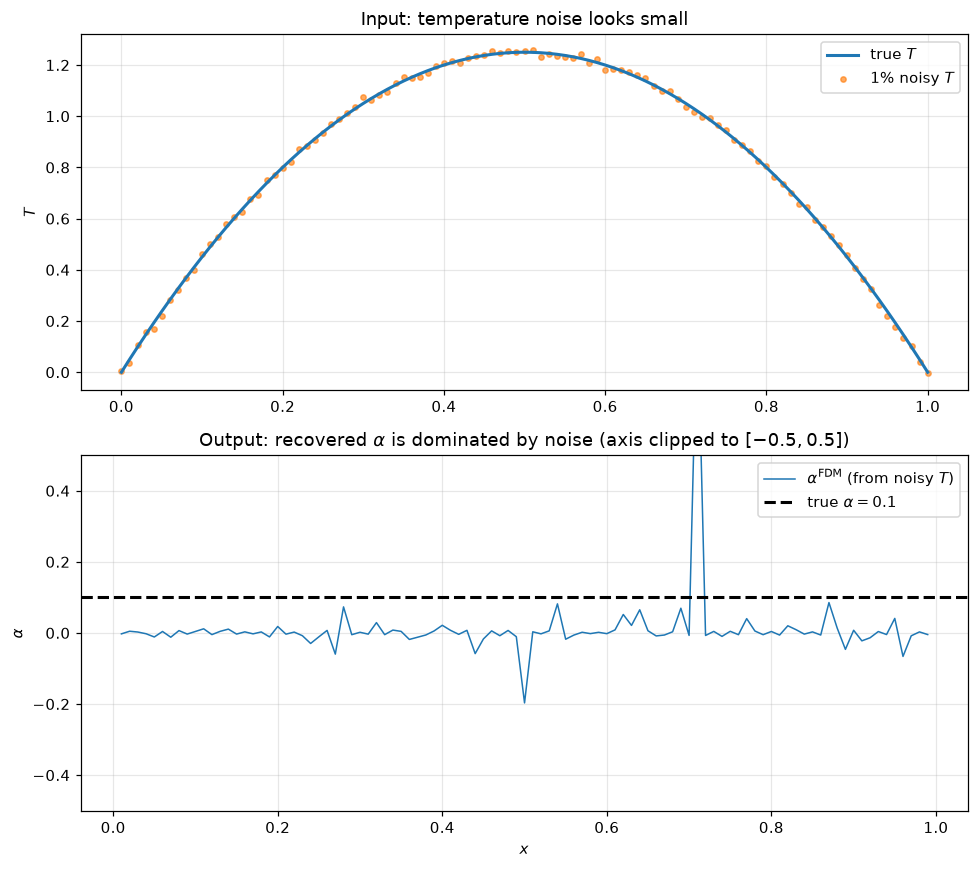

true alpha                       = 0.1
median of alpha estimates        = 0.0018
median relative error            = 98.2%  (robust; compare Tutorials 3)
std of alpha estimates           = 0.0983  (fragile: heavy-tailed 1/T''; see warning below)
fraction negative (unphysical)   = 48%
fraction within +/-50% of truth  = 6%
largest |alpha| estimate         = 0.9
(Single seed=42 realisation: the tail (max |alpha|) is seed-dependent; Monte Carlo below quantifies this.)


In [5]:
alpha_noisy, Txx_noisy = inverse_alpha_fdm(T_noisy, dx, q)
xi = x[1:-1]

# NOTE: y-axis below is deliberately clipped to [-0.5, 0.5] so the bulk stays
# visible; a few heavy-tailed outliers fall outside the view (see RMSE warning below).

fig, axes = plt.subplots(2, 1, figsize=(9, 8))

axes[0].plot(x, T_true, lw=2, label="true $T$")
axes[0].scatter(x, T_noisy, s=12, alpha=0.65, color="C1", label="1% noisy $T$")
axes[0].set_ylabel("$T$"); axes[0].set_title("Input: temperature noise looks small"); axes[0].legend()

axes[1].plot(xi, alpha_noisy, lw=1, label=r"$\alpha^{\rm FDM}$ (from noisy $T$)")
axes[1].axhline(alpha_true, ls="--", lw=2, color="k", label=r"true $\alpha=0.1$")
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_xlabel("$x$"); axes[1].set_ylabel(r"$\alpha$")
axes[1].set_title(r"Output: recovered $\alpha$ is dominated by noise (axis clipped to $[-0.5, 0.5]$)")
axes[1].legend()
plt.tight_layout(); plt.show()

within = np.mean(np.abs(alpha_noisy - alpha_true) < 0.5 * alpha_true)
med_relerr = np.median(np.abs(alpha_noisy - alpha_true) / alpha_true)
print(f"true alpha                       = {alpha_true}")
print(f"median of alpha estimates        = {np.median(alpha_noisy):.4f}")
print(f"median relative error            = {med_relerr:.1%}  (robust; compare Tutorials 3)")
print(f"std of alpha estimates           = {np.std(alpha_noisy):.4f}  (fragile: heavy-tailed 1/T''; see warning below)")
print(f"fraction negative (unphysical)   = {np.mean(alpha_noisy < 0):.0%}")
print(f"fraction within +/-50% of truth  = {within:.0%}")
print(f"largest |alpha| estimate         = {np.max(np.abs(alpha_noisy)):.1f}")
print("(Single seed=42 realisation: the tail (max |alpha|) is seed-dependent; Monte Carlo below quantifies this.)")


### Look at the curvature directly

The failure is easiest to see *before* the division. The true curvature is the flat dashed line at $-10$. What we measure scatters wildly around it.

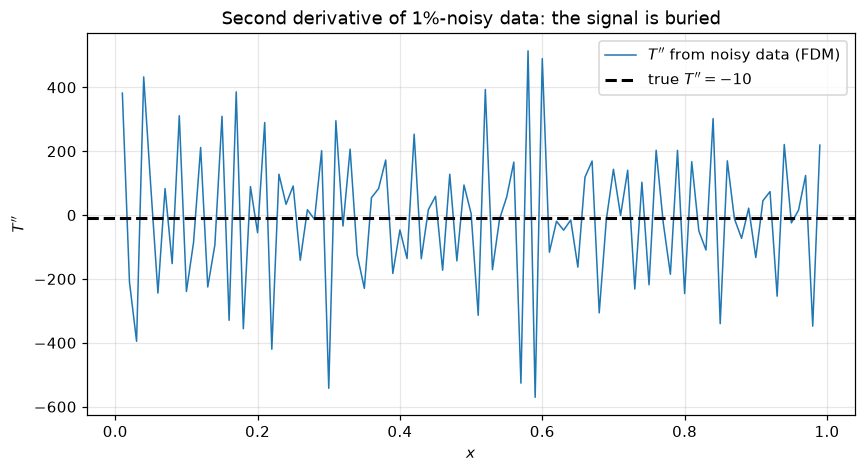

fraction of points with T'' > 0 (wrong sign): 48%


In [6]:
plt.figure(figsize=(9, 4.5))
plt.plot(xi, Txx_noisy, lw=1, label="$T''$ from noisy data (FDM)")
plt.axhline(Txx_true, ls="--", lw=2, color="k", label="true $T''=-10$")
plt.xlabel("$x$"); plt.ylabel("$T''$")
plt.title("Second derivative of 1%-noisy data: the signal is buried")
plt.legend(); plt.show()

print(f"fraction of points with T'' > 0 (wrong sign): {np.mean(Txx_noisy > 0):.0%}")

> **Take-away.** Whenever the noisy $T''$ has the wrong sign, $\alpha=-q/T''$ comes out negative, which is physically impossible. Whenever it is close to zero, $\alpha$ is huge. That is why the pointwise estimate is not merely noisy, it is *meaningless*.

## 8. Mesh refinement: finer is worse

In forward PDE work, a finer mesh means higher accuracy. Here the sensor noise $\sigma$ is a property of the instrument and does **not** shrink when we sample more densely. Since $\operatorname{Std}(\epsilon_{T''})=\sqrt6\,\sigma/\Delta x^2$, halving $\Delta x$ makes the differentiated noise **4x larger**.

We test this with a Monte Carlo study (200 noise realisations per grid) so the result does not depend on one lucky or unlucky random seed. For each grid we report:

* the measured and predicted noise in $T''$,
* the fraction of $\alpha$ estimates that land within $\pm50\%$ of the truth (a "usable estimate" rate),
* the fraction of negative (unphysical) estimates,
* $\mathrm{RMSE}(\alpha)$, which we include on purpose to show why it is a poor metric; see the warning below.

In [7]:
def mc_pointwise(N, eta=0.01, trials=200, seed=0):
    xx = np.linspace(0, L, N)
    ddx = xx[1] - xx[0]
    TT = analytical_temperature(xx, alpha_true, L, q, T0, TL)
    sig = eta * TT.max()
    # NOTE (fixed): offset seed by N so grids get independent streams.
    rng = np.random.default_rng(seed + N)
    Tn = TT + rng.normal(0.0, sig, (trials, N))
    Txx = (Tn[:, 2:] - 2 * Tn[:, 1:-1] + Tn[:, :-2]) / ddx**2
    a = -q / Txx
    return dict(
        N=N, dx=ddx, sigma=sig,
        theory_std=np.sqrt(6) * sig / ddx**2,
        emp_std=(Txx - Txx_true).std(),
        frac_ok=np.mean(np.abs(a - alpha_true) < 0.5 * alpha_true),
        frac_neg=np.mean(a < 0),
        rmse=np.sqrt(np.mean((a - alpha_true) ** 2)),
        med_relerr=np.median(np.abs(a - alpha_true) / alpha_true),
    )

Ns = [21, 41, 81, 161, 321, 641]
mc = [mc_pointwise(N) for N in Ns]

print(f'{"N":>5} {"dx":>9} {"std(Txx) theory":>16} {"std(Txx) measured":>18} '
      f'{"usable a":>9} {"negative a":>11} {"RMSE(a)":>9}')
for r in mc:
    print(f"{r['N']:5d} {r['dx']:9.2e} {r['theory_std']:16.1f} {r['emp_std']:18.1f} "
          f"{r['frac_ok']:9.1%} {r['frac_neg']:11.1%} {r['rmse']:9.3f}")


    N        dx  std(Txx) theory  std(Txx) measured  usable a  negative a   RMSE(a)
   21  5.00e-02             12.2               11.9     40.4%       20.0%     3.847
   41  2.50e-02             49.0               49.0     11.4%       41.3%     2.159
   81  1.25e-02            196.0              197.3      2.6%       47.8%     0.989
  161  6.25e-03            783.8              789.7      0.6%       49.6%     0.477
  321  3.13e-03           3135.3             3124.3      0.2%       49.7%     0.129
  641  1.56e-03          12541.4            12492.0      0.1%       50.1%     0.126


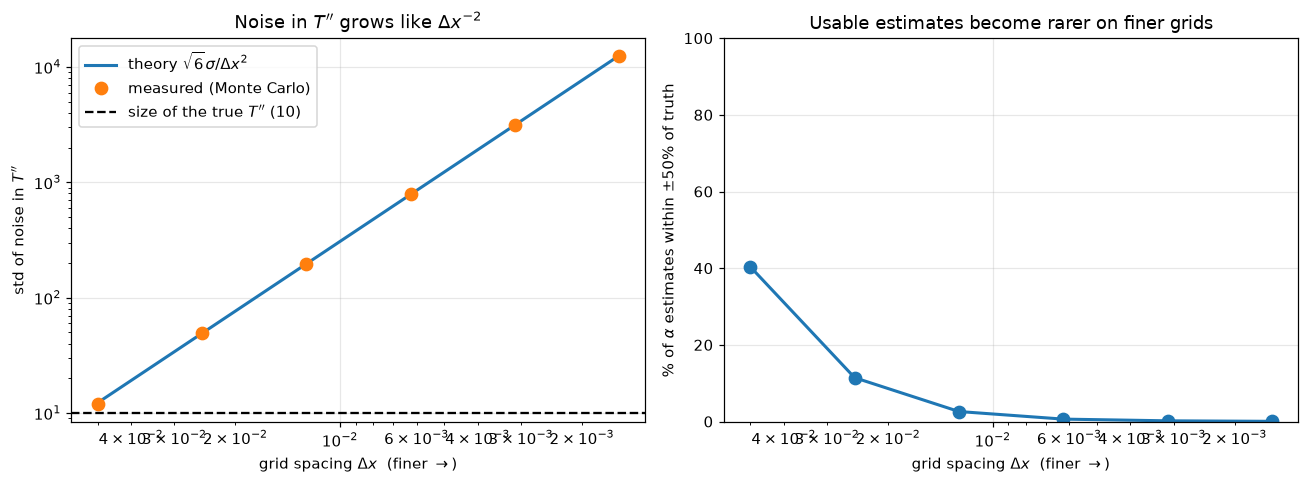

In [8]:
dxs = np.array([r["dx"] for r in mc])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].loglog(dxs, [r["theory_std"] for r in mc], "-", lw=2, label=r"theory $\sqrt{6}\sigma/\Delta x^2$")
axes[0].loglog(dxs, [r["emp_std"] for r in mc], "o", ms=8, label="measured (Monte Carlo)")
axes[0].axhline(abs(Txx_true), ls="--", color="k", label="size of the true $T''$ (10)")
axes[0].invert_xaxis()
axes[0].set_xlabel(r"grid spacing $\Delta x$  (finer $\rightarrow$)")
axes[0].set_ylabel("std of noise in $T''$")
axes[0].set_title("Noise in $T''$ grows like $\\Delta x^{-2}$")
axes[0].legend()

axes[1].semilogx(dxs, [100 * r["frac_ok"] for r in mc], "o-", lw=2, ms=8)
axes[1].invert_xaxis()
axes[1].set_xlabel(r"grid spacing $\Delta x$  (finer $\rightarrow$)")
axes[1].set_ylabel(r"% of $\alpha$ estimates within $\pm$50% of truth")
axes[1].set_title("Usable estimates become rarer on finer grids")
axes[1].set_ylim(0, 100)

plt.tight_layout(); plt.show()

**What the table and plots show**

* The measured noise matches the $\Delta x^{-2}$ prediction closely.
* Already on the coarsest grid the noise in $T''$ (about 12) is comparable to the signal (10), and it overwhelms it on finer grids.
* The fraction of usable estimates falls steadily, from about 40% to essentially zero, as the mesh is refined.
* About half of all estimates are negative once the noise dominates (a coin flip on the sign of $T''$).

> **Warning: RMSE$(\alpha)$ is a misleading metric here.** Look at its column: it is erratic/non-monotonic across grids (exact values are seed-dependent,  try a different seed) and can *fall* on fine grids, which looks like improvement. It is not. Two effects are at work. (i) $\alpha=-q/T''$ is heavy-tailed: whenever the noisy curvature lands near zero, $\alpha$ is enormous, and a few such outliers dominate the RMSE on coarse grids. (ii) On fine grids the noise in $T''$ is so large that $\alpha$ is typically a tiny number near **zero**, so the error settles near $|0-0.1|=0.1$-$0.3$ even though the estimates are useless. Compare with the "usable estimate" column, which tells the true story: it falls monotonically from about 40% to essentially 0%. Always examine the error in $T''$ and the *distribution* of the estimates, not one summary number.

Below are single realisations (seed 42) for each grid, with the vertical axis clipped to the 1st-99th percentile so the few extreme outliers do not hide the rest.


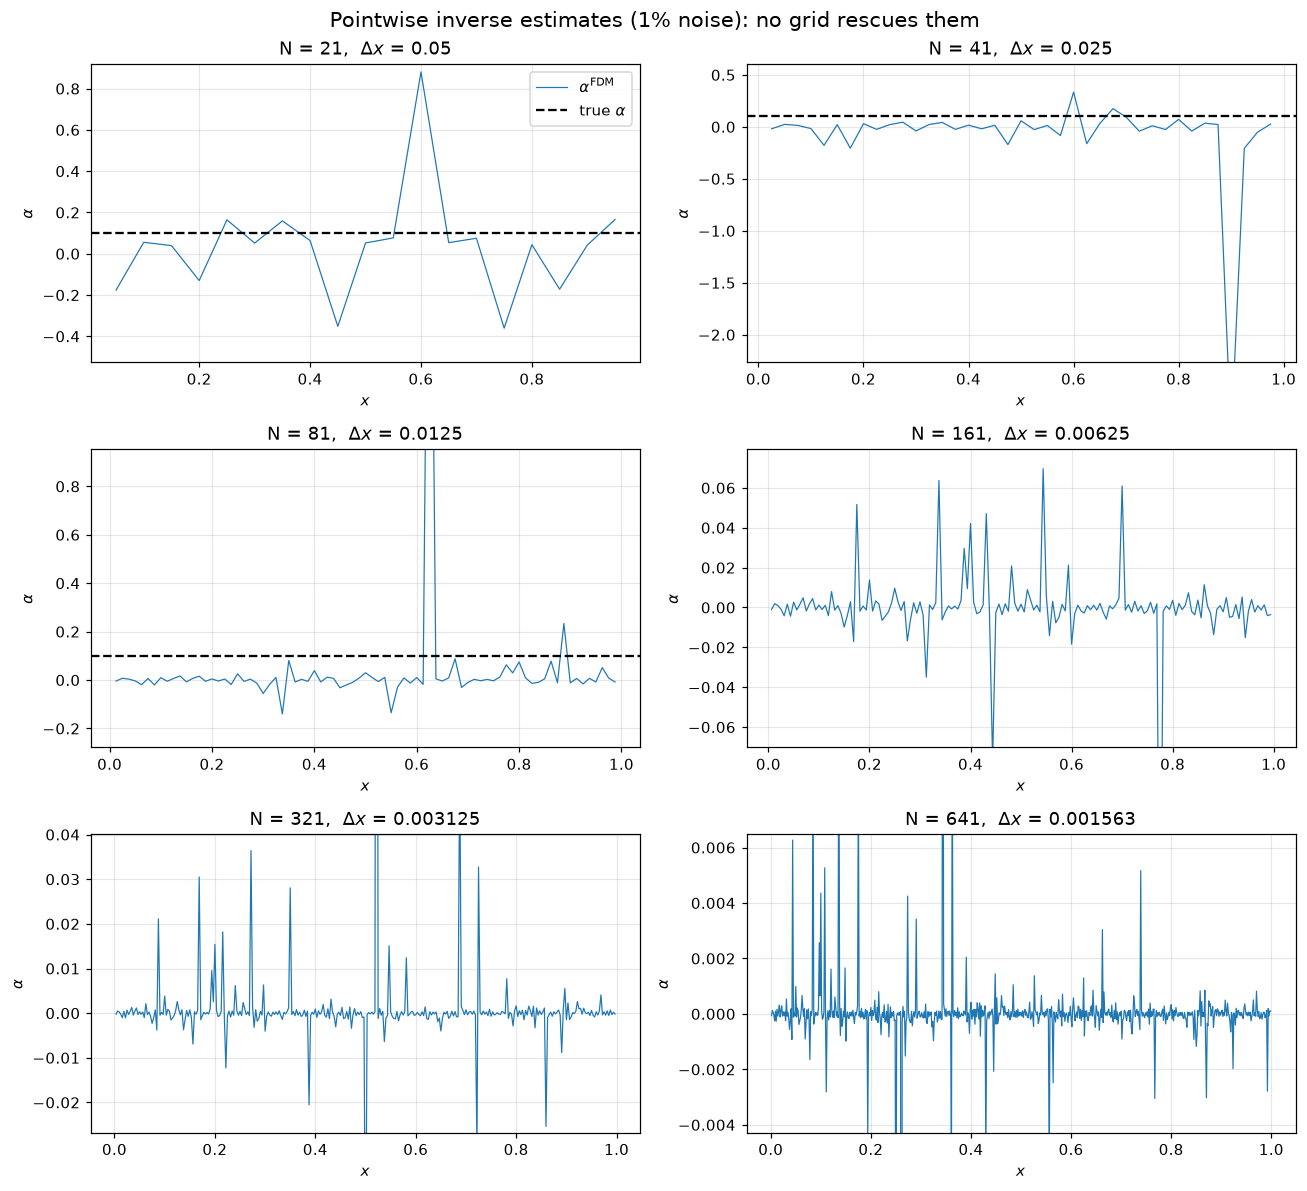

In [9]:
def run_case(N, noise_level=0.01, seed=42):
    xx = np.linspace(0, L, N)
    ddx = xx[1] - xx[0]
    TT = analytical_temperature(xx, alpha_true, L, q, T0, TL)
    TTn, sig = add_noise(TT, noise_level, seed)
    aa, TTxx = inverse_alpha_fdm(TTn, ddx, q)
    return {"N": N, "xi": xx[1:-1], "dx": ddx, "alpha": aa}

results = [run_case(N, 0.01, 42) for N in Ns]

fig, axes = plt.subplots(3, 2, figsize=(12, 11))
for ax, r in zip(axes.ravel(), results):
    a = r["alpha"]
    lo, hi = np.percentile(a[np.isfinite(a)], [1, 99])
    margin = 0.15 * max(hi - lo, 1e-12)
    ax.plot(r["xi"], a, lw=0.8, label=r"$\alpha^{\rm FDM}$")
    ax.axhline(alpha_true, ls="--", lw=1.5, color="k", label=r"true $\alpha$")
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_title(f"N = {r['N']},  $\\Delta x$ = {r['dx']:.4g}")
    ax.set_xlabel("$x$"); ax.set_ylabel(r"$\alpha$")
axes[0, 0].legend()
fig.suptitle("Pointwise inverse estimates (1% noise): no grid rescues them", fontsize=14)
fig.tight_layout(); plt.show()

## 9. Control experiment: no measurement noise

Set $\sigma=0$. If the failure were caused by a bug in the finite-difference stencil, it would show up here too. It does not: the errors are around $10^{-15}$ to $10^{-12}$.

But look closely at *how* the error behaves as the grid is refined.

    N         dx    RMSE(alpha)    ratio to previous
   21  5.000e-02      1.017e-15 
   41  2.500e-02      3.623e-15                  3.6
   81  1.250e-02      1.624e-14                  4.5
  161  6.250e-03      5.783e-14                  3.6
  321  3.125e-03      2.686e-13                  4.6
  641  1.563e-03      9.530e-13                  3.5


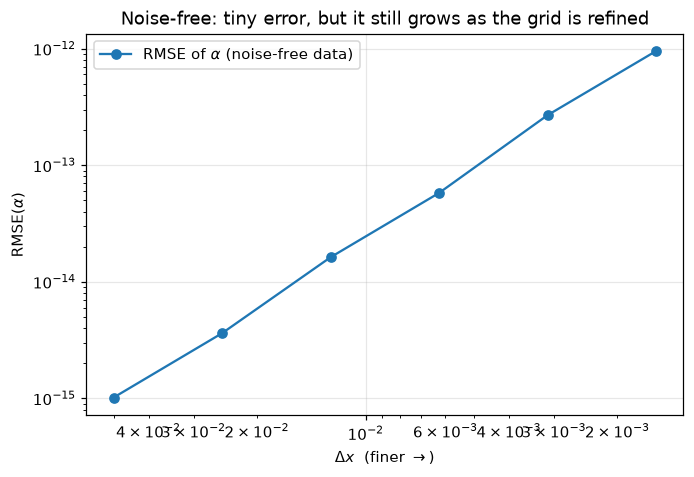

In [10]:
clean = []
for N in Ns:
    xx = np.linspace(0, L, N); ddx = xx[1] - xx[0]
    TT = analytical_temperature(xx, alpha_true, L, q, T0, TL)
    aa, _ = inverse_alpha_fdm(TT, ddx, q)
    clean.append((N, ddx, np.sqrt(np.mean((aa - alpha_true) ** 2))))

print(f"{'N':>5} {'dx':>10} {'RMSE(alpha)':>14} {'ratio to previous':>20}")
prev = None
for N, ddx, e in clean:
    print(f"{N:5d} {ddx:10.3e} {e:14.3e} {'' if prev is None else f'{e/prev:20.1f}'}")
    prev = e

plt.figure(figsize=(7, 4.5))
plt.loglog([c[1] for c in clean], [c[2] for c in clean], "o-", label="RMSE of $\\alpha$ (noise-free data)")
plt.gca().invert_xaxis()
plt.xlabel(r"$\Delta x$  (finer $\rightarrow$)"); plt.ylabel(r"RMSE$(\alpha)$")
plt.title("Noise-free: tiny error, but it still grows as the grid is refined")
plt.legend(); plt.show()

**Interpretation.**

* The stencil is exact for a quadratic $T$, so there is *no truncation error* to converge. The error is purely **floating-point round-off**.
* That round-off behaves like a tiny measurement noise of size $\sim 10^{-16}$ (machine precision) on every $T_i$. The error grows by roughly a factor of 4 each time $\Delta x$ is halved, which is exactly the same $\Delta x^{-2}$ law as Section 6.

So even with no sensor noise at all, differentiating twice amplifies whatever tiny errors are present. Measurement noise is just a much larger version of the same effect.

> **A caveat for general problems.** For a non-polynomial $T$, the central difference does have a truncation error $\propto\Delta x^{2}$, which *decreases* with refinement. The total error is then roughly $C_1\Delta x^{2}+C_2\,\sigma/\Delta x^{2}$: a trade-off with a best (finite) $\Delta x$, not "finer is always better". Our test case isolates the noise term because the truncation term is zero.

## What you should take away (Part 2)

- 1% noise looks harmless in $T$ but is ~30x the signal *inside the stencil*.
- The pointwise inverse is meaningless on noisy data  and refinement makes it worse.
- Even pure round-off obeys the $\Delta x^{-2}$ law, so the stencil is not "buggy".

**Next:** Part 3 explains *why* in frequency space and shows a fix that uses all the data at once.

### Exercises
1. **Noise threshold.** With $\eta=0.1\%$, solve $\sqrt6\ \sigma/\Delta x^2=10$ for the grid spacing where noise in $T''$ equals the signal. Check it with `mc_pointwise`.
2. **Smoothing.** Smooth $T^{\rm obs}$ with a moving average before differentiating. Does the bias near the peak grow? Why?
